In [16]:
import pandas as pd
import numpy as np
import itertools
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt
matplotlib.style.use('default')

/usr/local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Melhor modelo ARIMA: Ordem=(0, 0, 1), AIC=244.81648634326612
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   90
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -119.408
Date:                Fri, 29 Nov 2024   AIC                            244.816
Time:                        21:17:37   BIC                            252.316
Sample:                             0   HQIC                           247.841
                                 - 90                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1512      0.041      3.732      0.000       0.072       0.231
ma.L1         -0.5816      0.082     -7.064      0.000      -0.743    

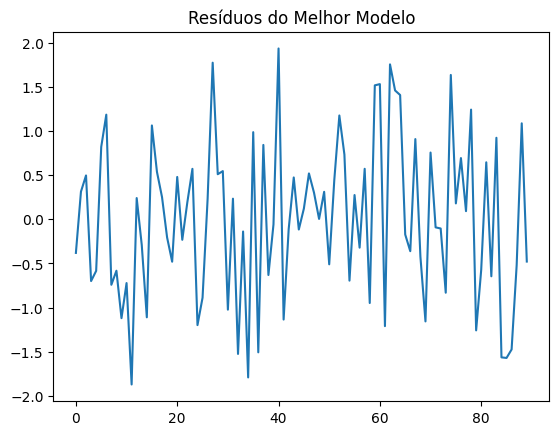

In [17]:
# Função para encontrar o melhor modelo ARIMA
def find_best_arima(series, p_range, d_range, q_range):
    best_aic = float('inf')
    best_order = None
    best_model = None

    # Testar todas as combinações de p, d, q
    for p, d, q in itertools.product(p_range, d_range, q_range):
        try:
            # Ajustar o modelo
            model = ARIMA(series, order=(p, d, q))
            results = model.fit()
            # Comparar AIC
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = (p, d, q)
                best_model = results
        except Exception as e:
            # Ignorar combinações inválidas
            continue

    print(f"Melhor modelo ARIMA: Ordem={best_order}, AIC={best_aic}")
    return best_model, best_order

series = pd.Series([-0.23, 0.63, 0.48, -0.83, -0.03, 1.31, 0.86, -1.28, 0.0, -0.63, 0.08, -1.3, 1.48, -0.28, -0.79, 1.86, 0.07, 0.09, -0.2, -0.21, 0.91, -0.36, 0.48, 0.61, -1.38, -0.04, 0.9, 1.79, -0.37, 0.4, -1.19, 0.98, -1.51, 0.9, -1.56, 2.18, -1.93, 1.87, -0.97, 0.46, 2.12, -2.11, 0.7, 0.69, -0.24, 0.34, 0.6, 0.15, -0.02, 0.46, -0.54, 0.89, 1.07, 0.2, -0.97, 0.83, -0.33, 0.91, -1.13, 2.22, 0.8, -1.95, 2.61, 0.59, 0.71, -0.84, -0.11, 1.27, -0.8, -0.76, 1.58, -0.38, 0.1, -0.62, 2.27, -0.62, 0.74, -0.16, 1.34, -1.83, 0.31, 1.13, -0.87, 1.45, -1.95, -0.51, -0.41, 0.49, 1.54, -0.96])

# Definir intervalos para p, d, q
p_range = range(0, 3)  # Intervalo para p
d_range = range(0, 2)  # Intervalo para d
q_range = range(0, 3)  # Intervalo para q

# Encontrar o melhor modelo
best_model, best_order = find_best_arima(series, p_range, d_range, q_range)

# Resumo do melhor modelo
if best_model:
    print(best_model.summary())

    # Analisar os resíduos do melhor modelo
    residuals = best_model.resid
    residuals.plot(title="Resíduos do Melhor Modelo")
    plt.show()

/usr/local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/site-packages/st

Melhor modelo ARIMA: Ordem=(1, 1, 1), AIC=267.0143096807744
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   65
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -130.507
Date:                Fri, 29 Nov 2024   AIC                            267.014
Time:                        21:19:01   BIC                            273.491
Sample:                             0   HQIC                           269.566
                                 - 65                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9476      0.083     11.443      0.000       0.785       1.110
ma.L1         -0.7379      0.164     -4.501      0.000      -1.059     

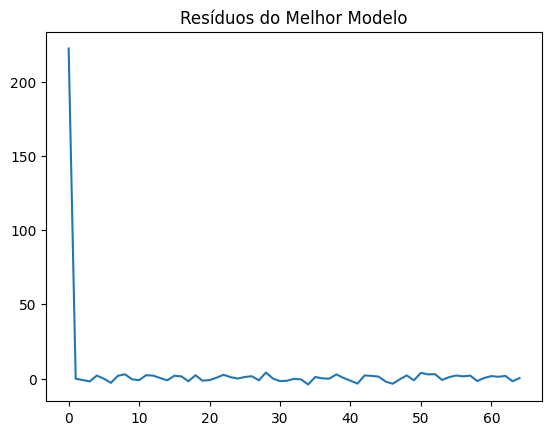

In [18]:
# Função para encontrar o melhor modelo ARIMA
def find_best_arima(series, p_range, d_range, q_range):
    best_aic = float('inf')
    best_order = None
    best_model = None

    # Testar todas as combinações de p, d, q
    for p, d, q in itertools.product(p_range, d_range, q_range):
        try:
            # Ajustar o modelo
            model = ARIMA(series, order=(p, d, q))
            results = model.fit()
            # Comparar AIC
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = (p, d, q)
                best_model = results
        except Exception as e:
            # Ignorar combinações inválidas
            continue

    print(f"Melhor modelo ARIMA: Ordem={best_order}, AIC={best_aic}")
    return best_model, best_order

series = pd.Series([222.34, 222.24, 221.17, 218.88, 220.05, 219.61, 216.4, 217.33, 219.69, 219.32, 218.25, 220.3, 222.54, 223.56, 223.07, 225.36, 227.6, 226.82, 229.69, 229.3, 228.96, 229.99, 233.05, 235.0, 236.17, 238.31, 241.14, 241.48, 246.74, 248.73, 248.83, 248.78, 249.61, 249.9, 246.65, 247.57, 247.76, 247.81, 250.68, 251.8, 251.07, 248.05, 249.76, 251.66, 253.41, 252.04, 248.78, 247.76, 249.27, 247.95, 251.41, 254.67, 258.62, 259.25, 261.49, 264.95, 268.21, 272.16, 272.79, 275.03, 278.49, 281.75, 285.7, 286.33, 288.57])

# Definir intervalos para p, d, q
p_range = range(0, 3)  # Intervalo para p
d_range = range(0, 2)  # Intervalo para d
q_range = range(0, 3)  # Intervalo para q

# Encontrar o melhor modelo
best_model, best_order = find_best_arima(series, p_range, d_range, q_range)

# Resumo do melhor modelo
if best_model:
    print(best_model.summary())

    # Analisar os resíduos do melhor modelo
    residuals = best_model.resid
    residuals.plot(title="Resíduos do Melhor Modelo")
    plt.show()

/var/folders/ct/6tj9598n58x450wty030kyqc0000gn/T/ipykernel_6113/3926798675.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data1.index = pd.date_range(start="2020-01-01", periods=len(data1), freq="M")
/var/folders/ct/6tj9598n58x450wty030kyqc0000gn/T/ipykernel_6113/3926798675.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data2.index = pd.date_range(start="2020-01-01", periods=len(data2), freq="M")



Série 1:
Teste de Dickey-Fuller:
Estatística de teste: -9.813093569687899
Valor-p: 5.589199949525307e-17
Valores críticos: {'1%': np.float64(-3.506944401824286), '5%': np.float64(-2.894989819214876), '10%': np.float64(-2.584614550619835)}
A série é estacionária.


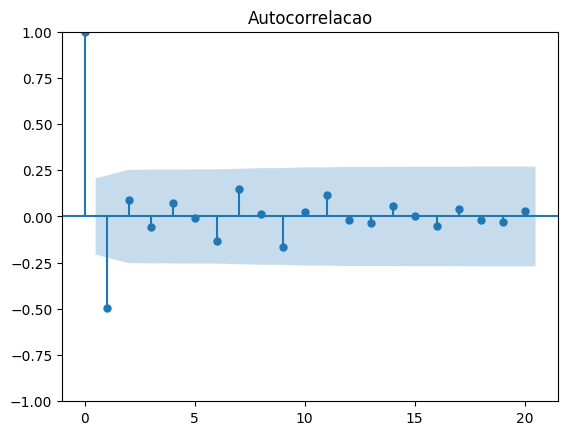

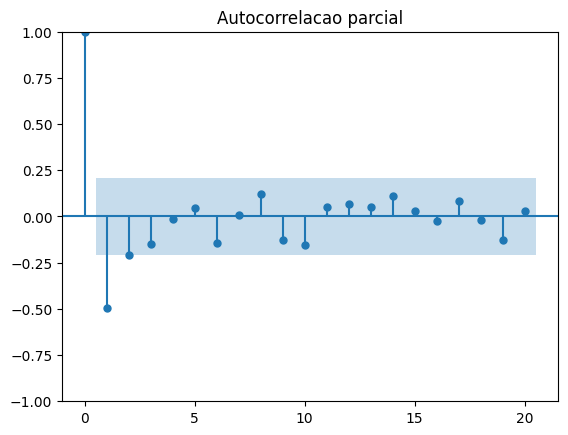

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   90
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -119.408
Date:                Fri, 29 Nov 2024   AIC                            244.816
Time:                        21:23:37   BIC                            252.316
Sample:                    01-31-2020   HQIC                           247.841
                         - 06-30-2027                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1512      0.041      3.732      0.000       0.072       0.231
ma.L1         -0.5816      0.082     -7.064      0.000      -0.743      -0.420
sigma2         0.8278      0.155      5.343      0.0

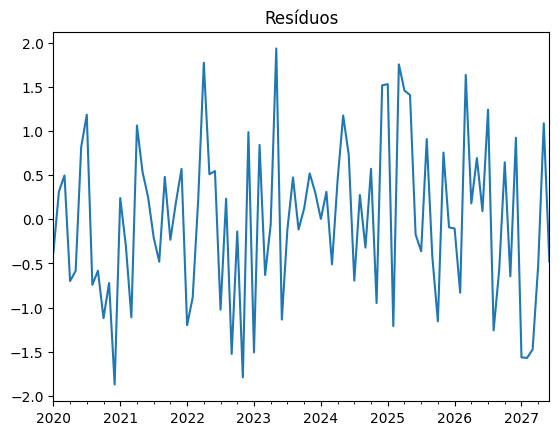

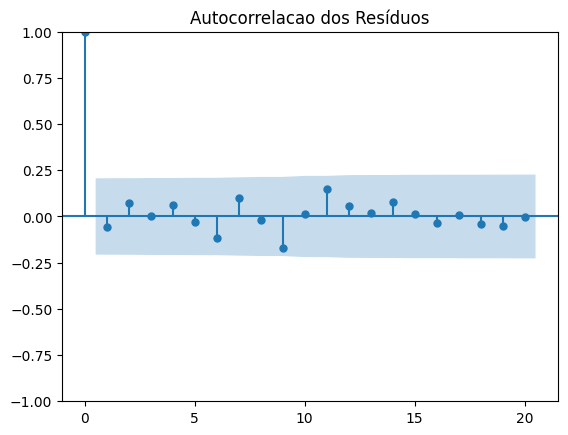

/var/folders/ct/6tj9598n58x450wty030kyqc0000gn/T/ipykernel_6113/3926798675.py:51: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=series.index[-1] + pd.DateOffset(1), periods=steps, freq="M")


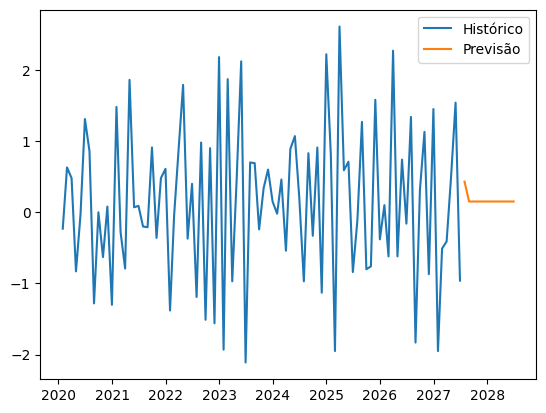


Série 2:
Teste de Dickey-Fuller:
Estatística de teste: 1.4904930052974548
Valor-p: 0.9974888455868237
Valores críticos: {'1%': np.float64(-3.5386953618719676), '5%': np.float64(-2.9086446751210775), '10%': np.float64(-2.591896782564878)}
A série não é estacionária.


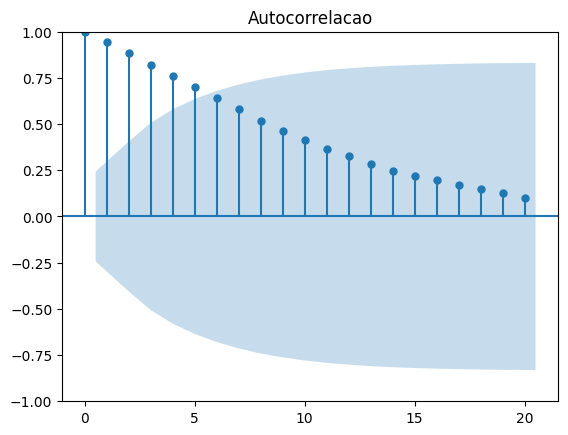

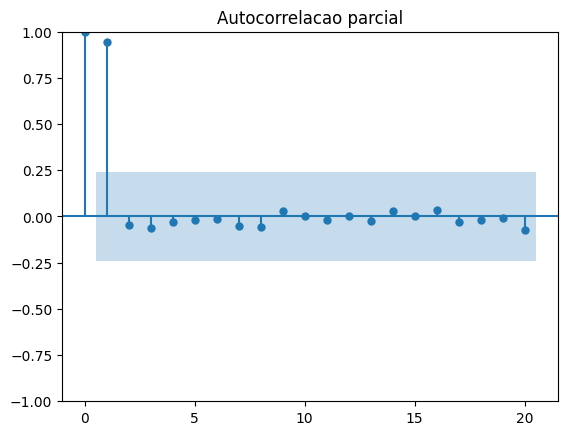

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   65
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -130.507
Date:                Fri, 29 Nov 2024   AIC                            267.014
Time:                        21:23:38   BIC                            273.491
Sample:                    01-31-2020   HQIC                           269.566
                         - 05-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9476      0.083     11.443      0.000       0.785       1.110
ma.L1         -0.7379      0.164     -4.501      0.000      -1.059      -0.417
sigma2         3.4214      0.772      4.431      0.0

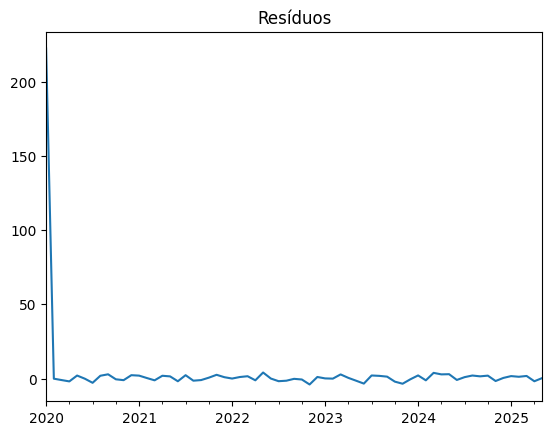

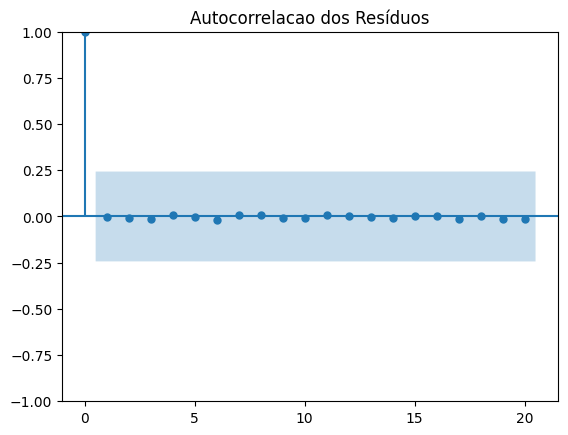

/var/folders/ct/6tj9598n58x450wty030kyqc0000gn/T/ipykernel_6113/3926798675.py:51: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=series.index[-1] + pd.DateOffset(1), periods=steps, freq="M")


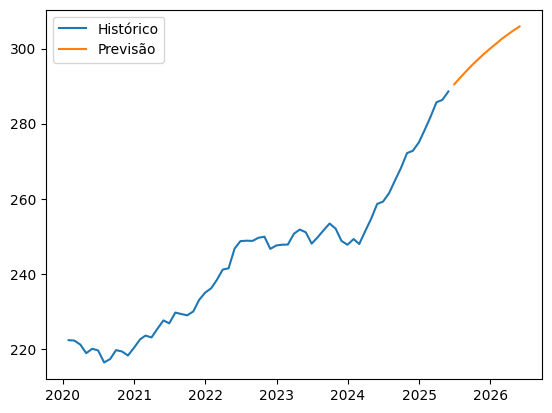

2025-06-30    290.476663
2025-07-31    292.283498
2025-08-31    293.995731
2025-09-30    295.618317
2025-10-31    297.155948
2025-11-30    298.613073
2025-12-31    299.993906
2026-01-31    301.302443
2026-02-28    302.542468
2026-03-31    303.717569
2026-04-30    304.831144
2026-05-31    305.886416
Freq: ME, Name: predicted_mean, dtype: float64

In [22]:
# Função para carregar e visualizar as séries temporais
def load_data(series1, series2):
    data1 = pd.Series(series1)
    data2 = pd.Series(series2)
    data1.index = pd.date_range(start="2020-01-01", periods=len(data1), freq="M")
    data2.index = pd.date_range(start="2020-01-01", periods=len(data2), freq="M")
    return data1, data2

# Teste de estacionariedade (Dickey-Fuller)
def test_stationarity(series):
    result = adfuller(series)
    print(f"Teste de Dickey-Fuller:")
    print(f"Estatística de teste: {result[0]}")
    print(f"Valor-p: {result[1]}")
    print(f"Valores críticos: {result[4]}")
    if result[1] <= 0.05:
        print("A série é estacionária.")
    else:
        print("A série não é estacionária.")

# Identificação do modelo ARIMA
def identify_model(series):
    plot_acf(series, lags=20)
    plt.title("Autocorrelacao")
    plt.show()
    plot_pacf(series, lags=20)
    plt.title("Autocorrelacao parcial")
    plt.show()

# Ajustar modelo ARIMA
def fit_arima(series, order):
    model = ARIMA(series, order=order)
    results = model.fit()
    print(results.summary())
    return results

# Análise de resíduos
def analyze_residuals(residuals):
    print("Análise dos resíduos:")
    ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)
    print(f"Ljung-Box Test:\n{ljung_box}")
    residuals.plot(title="Resíduos")
    plt.show()
    plot_acf(residuals, lags=20)
    plt.title("Autocorrelacao dos Resíduos")
    plt.show()

# Previsão
def forecast(series, model, steps=12):
    forecast = model.forecast(steps=steps)
    forecast_index = pd.date_range(start=series.index[-1] + pd.DateOffset(1), periods=steps, freq="M")
    forecast_series = pd.Series(forecast, index=forecast_index)
    plt.plot(series, label="Histórico")
    plt.plot(forecast_series, label="Previsão")
    plt.legend()
    plt.show()
    return forecast_series

# Simular as séries temporais dos arquivos
series1 = np.array([-0.23, 0.63, 0.48, -0.83, -0.03, 1.31, 0.86, -1.28, 0.0, -0.63, 0.08, -1.3, 1.48, -0.28, -0.79, 1.86, 0.07, 0.09, -0.2, -0.21, 0.91, -0.36, 0.48, 0.61, -1.38, -0.04, 0.9, 1.79, -0.37, 0.4, -1.19, 0.98, -1.51, 0.9, -1.56, 2.18, -1.93, 1.87, -0.97, 0.46, 2.12, -2.11, 0.7, 0.69, -0.24, 0.34, 0.6, 0.15, -0.02, 0.46, -0.54, 0.89, 1.07, 0.2, -0.97, 0.83, -0.33, 0.91, -1.13, 2.22, 0.8, -1.95, 2.61, 0.59, 0.71, -0.84, -0.11, 1.27, -0.8, -0.76, 1.58, -0.38, 0.1, -0.62, 2.27, -0.62, 0.74, -0.16, 1.34, -1.83, 0.31, 1.13, -0.87, 1.45, -1.95, -0.51, -0.41, 0.49, 1.54, -0.96])
series2 = np.array([222.34, 222.24, 221.17, 218.88, 220.05, 219.61, 216.4, 217.33, 219.69, 219.32, 218.25, 220.3, 222.54, 223.56, 223.07, 225.36, 227.6, 226.82, 229.69, 229.3, 228.96, 229.99, 233.05, 235.0, 236.17, 238.31, 241.14, 241.48, 246.74, 248.73, 248.83, 248.78, 249.61, 249.9, 246.65, 247.57, 247.76, 247.81, 250.68, 251.8, 251.07, 248.05, 249.76, 251.66, 253.41, 252.04, 248.78, 247.76, 249.27, 247.95, 251.41, 254.67, 258.62, 259.25, 261.49, 264.95, 268.21, 272.16, 272.79, 275.03, 278.49, 281.75, 285.7, 286.33, 288.57])

# Carregar os dados
data1, data2 = load_data(series1, series2)

# Série 1
print("\nSérie 1:")
test_stationarity(data1)
identify_model(data1)
model1 = fit_arima(data1, order=(0, 0, 1))
analyze_residuals(model1.resid)
forecast(data1, model1)

# Série 2
print("\nSérie 2:")
test_stationarity(data2)
identify_model(data2)
model2 = fit_arima(data2, order=(1, 1, 1))
analyze_residuals(model2.resid)
forecast(data2, model2)
